In [ ]:
!pip install unidecode


[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install rdkit

     ---------------------------------------- 23.6/23.6 MB 2.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import unidecode
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Mount Google Drive (uncomment if using Colab)
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# Load and preprocess data
try:
    text = unidecode.unidecode(open('data_for_generation_mol.txt').read())
except:
    print("⚠️ Data file not found. Please update the file path.")

print(f"📊 Total characters in dataset: {len(text):,}")
print(f"🔤 First 100 characters: {text[:100]}")

📊 Total characters in dataset: 75,602,998
🔤 First 100 characters: <COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56><C[S+]


In [4]:
# Extract unique characters and build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\n📚 Vocabulary: {''.join(chars)}")
print(f"📏 Vocabulary size: {vocab_size}")


📚 Vocabulary: #%()+-./0123456789<=>@ABCFHIKLMNOPRSTVXZ[\]abcegilnoprstu
📏 Vocabulary size: 57


In [5]:
# Create character mappings
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Test encoding/decoding
sample_text = text[:20]
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"\n🔍 Sample encoding test:")
print(f"Original: {sample_text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")
print(f"✅ Encoding/Decoding works: {sample_text == decoded}")


🔍 Sample encoding test:
Original: <COc1ccc2[C@@H]3[C@H
Encoded: [18, 24, 32, 45, 9, 45, 45, 45, 10, 40, 24, 21, 21, 26, 42, 11, 40, 24, 21, 26]
Decoded: <COc1ccc2[C@@H]3[C@H
✅ Encoding/Decoding works: True


In [6]:
# Encode entire dataset
data = torch.tensor(encode(text), dtype=torch.long)
print(f"\n📈 Dataset shape: {data.shape}, dtype: {data.dtype}")
print(f"📊 First 20 tokens: {data[:20].tolist()}")


📈 Dataset shape: torch.Size([75602998]), dtype: torch.int64
📊 First 20 tokens: [18, 24, 32, 45, 9, 45, 45, 45, 10, 40, 24, 21, 21, 26, 42, 11, 40, 24, 21, 26]


## Data Splitting and Batch Generation

In [7]:
# Improved hyperparameters
batch_size = 32        # Increased batch size for better gradients
block_size = 256       # Increased context length for better SMILES learning
learning_rate = 1e-4   # Better learning rate
n_head = 12             # Reduced for efficiency
n_embd = n_head * 32    # Reasonable embedding size (384)
ff_size_factor = 4     # Standard transformer ratio
n_layer = 12            # Sufficient depth
dropout = 0.15          # Regularization

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cpu


In [9]:
# Split data into train/validation
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 68,042,698 tokens
📊 Val data: 7,560,300 tokens


In [10]:
def get_batch(split):
    """Generate a batch of training data"""
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# Test batch generation
xb, yb = get_batch('train')
print(f"\n🔢 Batch shapes:")
print(f"Input (x): {xb.shape}")
print(f"Target (y): {yb.shape}")

# Show example of training sequences
print(f"\n📝 Sample training sequences:")
for i in range(min(3, batch_size)):
    sample_x = decode(xb[i][:20].cpu().tolist())
    sample_y = decode(yb[i][:20].cpu().tolist())
    print(f"Sequence {i+1}:")
    print(f"  Input:  '{sample_x}'")
    print(f"  Target: '{sample_y}'")


🔢 Batch shapes:
Input (x): torch.Size([32, 256])
Target (y): torch.Size([32, 256])

📝 Sample training sequences:
Sequence 1:
  Input:  'H](CN1)NC(=O)[C@@H]('
  Target: '](CN1)NC(=O)[C@@H](N'
Sequence 2:
  Input:  '@H]3C[C@H](F)C4=CC(='
  Target: 'H]3C[C@H](F)C4=CC(=O'
Sequence 3:
  Input:  ')c4ccc(Cl)cc4)C2><CN'
  Target: 'c4ccc(Cl)cc4)C2><CN1'


In [11]:
# Model Architecture

class Head(nn.Module):
    """Single head of self-attention with improvements"""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Scaled dot-product attention with proper scaling
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """Multi-head attention with residual connection"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """Feed-forward network with GELU activation"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """Transformer block with pre-layer normalization"""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Pre-layer normalization (better for training stability)
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    """Improved DrugGPT model for SMILES generation"""

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """Initialize weights for better training"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        """Improved generation with temperature and top-k sampling"""
        self.eval()  # Set to evaluation mode

        with torch.no_grad():
            for _ in range(max_new_tokens):
                # Crop context to block_size
                idx_cond = idx[:, -block_size:]

                # Get predictions
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature

                # Apply top-k filtering if specified
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')

                # Sample from the distribution
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)

                # Check for end-of-sequence token
                if idx_next.item() == eos_token:
                    break

                # Append to sequence
                idx = torch.cat((idx, idx_next), dim=1)

        self.train()  # Back to training mode
        return idx

# Create and initialize model
model = DrugGPT()
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 21.42M
🏋️ Trainable parameters: 21.42M
💾 Model size: ~85.7MB


In [12]:
# Training Setup and Loss Estimation

# Training hyperparameters
max_iters = 10000
eval_interval = 200
eval_iters = 100
save_interval = 500
save_path = "improved_drugGPT.pt"

# Optimizer with weight decay for regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

@torch.no_grad()
def estimate_loss():
    """Estimate loss on train and validation sets"""
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()

    model.train()
    return out

def validate_smiles(smiles_list):
    """Validate SMILES strings using RDKit"""
    valid_smiles = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                # Additional validation: check if it can be converted back
                canonical_smi = Chem.MolToSmiles(mol)
                if canonical_smi:
                    valid_smiles.append(canonical_smi)
        except:
            continue
    return valid_smiles

def generate_smiles(model, n_samples=100, temperature=0.8, max_length=100):
    """Generate SMILES strings"""
    sos_token = encode('<')[0]
    eos_token = encode('>')[0]

    generated_smiles = []
    context = torch.tensor([[sos_token]], dtype=torch.long, device=device)

    for i in range(n_samples):
        try:
            # Generate sequence
            generated = model.generate(
                context,
                max_new_tokens=max_length,
                eos_token=eos_token,
                temperature=temperature,
                top_k=50  # Add top-k sampling for better diversity
            )

            # Decode and clean
            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()

            if smi:  # Only add non-empty strings
                generated_smiles.append(smi)

        except Exception as e:
            print(f"⚠️ Generation error for sample {i}: {e}")
            continue

    return generated_smiles

print("✅ Training functions ready!")

✅ Training functions ready!


🚀 Starting training for 10000 iterations...
📊 Batch size: 32, Block size: 256
🧠 Model: 21.4M parameters
Step    0 | Train: 4.0981 | Val: 4.0961 | LR: 1.00e-04 | Time: 185.6s
💾 Checkpoint saved at iteration 0
Step  200 | Train: 1.5698 | Val: 1.5904 | LR: 9.99e-05 | Time: 1215.4s
Step  400 | Train: 1.3727 | Val: 1.3957 | LR: 9.96e-05 | Time: 2780.5s
💾 Checkpoint saved at iteration 500
Step  600 | Train: 1.1010 | Val: 1.1365 | LR: 9.92e-05 | Time: 4335.9s
Step  800 | Train: 0.9991 | Val: 1.0288 | LR: 9.86e-05 | Time: 5873.8s
Step 1000 | Train: 0.9275 | Val: 0.9613 | LR: 9.78e-05 | Time: 8193.9s
💾 Checkpoint saved at iteration 1000
Step 1200 | Train: 0.8884 | Val: 0.9252 | LR: 9.68e-05 | Time: 10534.0s
Step 1400 | Train: 0.8529 | Val: 0.8908 | LR: 9.57e-05 | Time: 12869.7s
💾 Checkpoint saved at iteration 1500
Step 1600 | Train: 0.8437 | Val: 0.8782 | LR: 9.44e-05 | Time: 15206.1s
Step 1800 | Train: 0.8252 | Val: 0.8610 | LR: 9.30e-05 | Time: 17544.9s
Step 2000 | Train: 0.7975 | Val: 0.8363

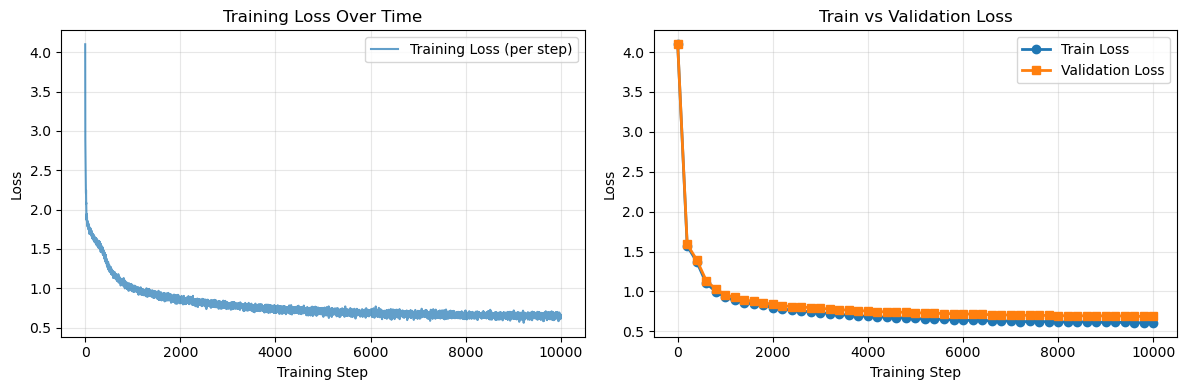

📊 Final Training Loss: 0.6086
📊 Final Validation Loss: 0.6899

🧪 Testing generation...
Generated samples: ['CC(C)C(=O)Nc1ccc(NC(=O)c2ccccc2)cc1', 'Cc1ccc(OCC(=O)NCCCC(=O)O)nc1', 'C[C@H]1O[C@@H](O[C@@H]2O[C@@H](CO)[C@@H](O)[C@@H]2O)[C@H](O)[C@H]1O', 'COC(=O)CCNC(=O)C(NC(=O)C)C(=O)OC', 'CC(C)N(CC(=O)Nc1ccc(cc1)S(=O)(=O)N2CCCC2)S(=O)(=O)N3CCCCC3']


In [13]:
# Training Loop

# Check for existing checkpoint
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            # Legacy: whole model saved
            model = checkpoint
            model.to(device)
            print("📍 Loaded legacy checkpoint")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        print("🔄 Starting fresh training...")
        resume_training = False

# Training variables
losses = []
train_losses = []
val_losses = []
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")
print(f"📊 Batch size: {batch_size}, Block size: {block_size}")
print(f"🧠 Model: {trainable_params/1e6:.1f}M parameters")

# Training loop
for iter_num in range(start_iter, max_iters):

    # Evaluate losses periodically
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Step {iter_num:4d} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | "
              f"Time: {elapsed_time:.1f}s")

    # Training step
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    # Save checkpoint
    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': {
                'vocab_size': vocab_size,
                'block_size': block_size,
                'n_embd': n_embd,
                'n_head': n_head,
                'n_layer': n_layer,
                'dropout': dropout
            }
        }
        torch.save(checkpoint, save_path)
        # torch.save(model.state_dict(), save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed!")
print(f"⏱️ Total training time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"🚀 Average time per iteration: {total_time/max_iters:.3f}s")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
eval_steps = range(0, len(train_losses) * eval_interval, eval_interval)
plt.plot(eval_steps, train_losses, 'o-', label='Train Loss', linewidth=2)
plt.plot(eval_steps, val_losses, 's-', label='Validation Loss', linewidth=2)
plt.title('Train vs Validation Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

# Quick generation test
print(f"\n🧪 Testing generation...")
test_samples = generate_smiles(model, n_samples=10, temperature=0.8)
print(f"Generated samples: {test_samples[:5]}")

In [33]:
# # Set path to utils_one.py
# utils_path = 'utils_first.py'

# # Add its directory to Python path
# import sys
# import os
# sys.path.append(os.path.dirname(utils_path))

# Import utility functions from the module utils_one
# from utils_first import
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

In [34]:
# ==========================================
# FIXED BENCHMARKING
# ==========================================
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
import random

# ==========================================
# FIRST FIX: PROPER NOVELTY CHECKING
# ==========================================

def load_training_smiles(file_path):
    """Load and parse training SMILES from the dataset"""
    try:
        with open(file_path, 'r') as f:
            text = f.read()

        # Extract SMILES from the training data
        # Assuming your data has format: <SMILES>
        training_smiles = []
        current_smi = ""
        in_smiles = False

        for char in text:
            if char == '<':
                in_smiles = True
                current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False
                current_smi = ""
            elif in_smiles:
                current_smi += char

        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))  # Remove duplicates

    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

# Load your training data
training_data_path = 'data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


In [35]:
# ==========================================
# IMPROVED GENERATION WITH BETTER SAMPLING
# ==========================================

def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100):
    """Generate SMILES with varying temperatures for diversity"""
    model.eval()
    sos_token = encode('<')[0]
    eos_token = encode('>')[0]

    generated_smiles = []

    for i in range(n_samples):
        # Vary temperature for diversity
        temp = random.uniform(temperature_range[0], temperature_range[1])

        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)

            generated = model.generate(
                context,
                max_new_tokens=max_length,
                eos_token=eos_token,
                temperature=temp,
                top_k=random.randint(30, 100)  # Vary top_k too
            )

            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()

            if smi and len(smi) > 5:  # Basic length filter
                generated_smiles.append(smi)

        except Exception as e:
            continue

        if i % 50 == 0:
            print(f"Generated {i}/{n_samples} molecules...")

    model.train()
    return generated_smiles


In [36]:
# ==========================================
# CORRECTED BENCHMARK FUNCTIONS
# ==========================================

def check_validity_batch(smiles_list):
    """Check validity of SMILES batch"""
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_novelty_correct(generated_smiles, training_smiles):
    """Check novelty against training set (CORRECTED)"""
    novel_smiles = []
    training_set = set(training_smiles)  # Convert to set for faster lookup

    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)

    return novel_smiles

def check_uniqueness_correct(smiles_list):
    """Remove duplicates"""
    return list(set(smiles_list))

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    """Calculate internal diversity using Tanimoto similarity"""
    from rdkit.Chem import AllChem, DataStructs

    if len(smiles_list) < 2:
        return 0.0

    # Sample if too many molecules
    if len(smiles_list) > sample_size:
        smiles_sample = random.sample(smiles_list, sample_size)
    else:
        smiles_sample = smiles_list

    # Convert to molecules and fingerprints
    mols = []
    fps = []

    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mols.append(mol)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048)
            fps.append(fp)

    if len(fps) < 2:
        return 0.0

    # Calculate pairwise similarities
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            similarities.append(sim)

    # Diversity = 1 - average similarity
    avg_similarity = np.mean(similarities)
    return 1 - avg_similarity

In [37]:

# ==========================================
# COMPREHENSIVE BENCHMARKING
# ==========================================

def run_comprehensive_benchmark(model, n_samples=1000):
    """Run complete benchmark with all metrics"""
    print("="*50)
    print("COMPREHENSIVE BENCHMARK")
    print("="*50)

    # Generate molecules
    print(f"Generating {n_samples} molecules...")
    generated_smiles = generate_diverse_smiles(model, n_samples=n_samples)
    print(f"Generated {len(generated_smiles)} raw molecules")

    # 1. Validity
    print("\n1. Checking validity...")
    valid_smiles = check_validity_batch(generated_smiles)
    validity = len(valid_smiles) / len(generated_smiles) if generated_smiles else 0
    print(f"Valid molecules: {len(valid_smiles)}/{len(generated_smiles)} ({validity:.2%})")

    if not valid_smiles:
        print("No valid molecules generated!")
        return

    # 2. Uniqueness
    print("\n2. Checking uniqueness...")
    unique_smiles = check_uniqueness_correct(valid_smiles)
    uniqueness = len(unique_smiles) / len(valid_smiles) if valid_smiles else 0
    print(f"Unique molecules: {len(unique_smiles)}/{len(valid_smiles)} ({uniqueness:.2%})")

    # 3. Novelty (CORRECTED)
    print("\n3. Checking novelty...")
    if training_smiles:
        novel_smiles = check_novelty_correct(unique_smiles, training_smiles)
        novelty = len(novel_smiles) / len(unique_smiles) if unique_smiles else 0
        print(f"Novel molecules: {len(novel_smiles)}/{len(unique_smiles)} ({novelty:.2%})")
    else:
        print("Warning: No training data loaded for novelty check")
        novel_smiles = unique_smiles
        novelty = 1.0

    # 4. Diversity
    print("\n4. Calculating diversity...")
    if len(novel_smiles) > 1:
        diversity = calculate_diversity_tanimoto(novel_smiles)
        print(f"Internal diversity: {diversity:.4f}")
    else:
        diversity = 0.0
        print("Not enough molecules for diversity calculation")

    # 5. Drug-likeness (Lipinski's Rule of Five)
    print("\n5. Checking drug-likeness...")
    drug_like_count = 0
    for smi in novel_smiles:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)

                # Lipinski's Rule of Five
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    drug_like_count += 1
        except:
            continue

    drug_likeness = drug_like_count / len(novel_smiles) if novel_smiles else 0
    print(f"Drug-like molecules: {drug_like_count}/{len(novel_smiles)} ({drug_likeness:.2%})")

    # Summary
    print("\n" + "="*50)
    print("BENCHMARK SUMMARY")
    print("="*50)
    print(f"Validity:      {validity:.2%}")
    print(f"Uniqueness:    {uniqueness:.2%}")
    print(f"Novelty:       {novelty:.2%}")
    print(f"Diversity:     {diversity:.4f}")
    print(f"Drug-likeness: {drug_likeness:.2%}")
    print("="*50)

    return {
        'validity': validity,
        'uniqueness': uniqueness,
        'novelty': novelty,
        'diversity': diversity,
        'drug_likeness': drug_likeness,
        'valid_smiles': valid_smiles,
        'unique_smiles': unique_smiles,
        'novel_smiles': novel_smiles
    }


In [38]:
# # Run the corrected benchmark
# print("Running corrected benchmark...")
# results = run_comprehensive_benchmark(model, n_samples=10)

### generate with untrained model

In [39]:
model = DrugGPT()
model = model.to(device)

In [40]:
generated_smiles = []
sos_token = encode('<')[0]
eos_token = encode('>')[0]
for i in range(10):
        # Vary temperature for diversity
        temp = random.uniform(0.7, 1.2)

        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)

            generated = model.generate(
                context,
                max_new_tokens=100,
                eos_token=eos_token,
                temperature=temp,
                top_k=random.randint(30, 100)  # Vary top_k too
            )

            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()

            if smi and len(smi) > 5:  # Basic length filter
                generated_smiles.append(smi)

        except Exception as e:
            continue

        # if i % 10 == 0:
        print(f"Generated {i}/{10} molecules...")


Generated 0/10 molecules...
Generated 1/10 molecules...
Generated 2/10 molecules...
Generated 3/10 molecules...
Generated 4/10 molecules...
Generated 5/10 molecules...
Generated 6/10 molecules...
Generated 7/10 molecules...
Generated 8/10 molecules...
Generated 9/10 molecules...


In [41]:
generated_smiles

['r86-P=sR=An]M59eHK9ai[-%RR]]N)4]M0SIeZ]#OI\\3b2Aer9]]4]',
 'n2t)]O/5)ZN=MBK3H]6\\[atSZ))V9RP9[s@',
 'HHC0pSV[4Vs6RHH]Aooi(toZeP[(4KZ=e9TXtMat=\\)iosMa4S-9oIVu-i-#ORSTZC]]ZTtRT](=XHF)ZHA/(R=)1oB)ptZR30A',
 'NpBiNs3/7Bt@-O6-TF-O9NlCC2oOsZHlaro@F5BFclR(o3LZnHKiAM]M]7OR14A--10uc-+HRrcZ114K4tAtuZV+P]socRZ6.',
 'CLAon2R63[I5FN6H[]e\\a]OlHia\\4Fa9(BAr6%OZpP2-[Ip9XNRiZ@t1ro()t)p#-22irs47%5I-a%(t5ncN-=u(5-]-1#bFio(F',
 '7n]=aVKnHK+i9)nsNoB)P-]Rl]lo9rrrT(FlbT]1X]A-3O2',
 'i]/)B-oiKK7]RC.20ei)7o',
 'C]gO6sM][(-9(H%SV=[t[3M8]43\\)A\\LoT0aA@HMeiiLV(8TiaMV=2=HZVr.s]14sRa+R43T/X@K=]99]R]gFT\\a)p4t-u\\aFF',
 'el[[(a#rSI[N(=]AM]OV9HTOiaF%Ss]6Fa=b\\9(']

------------------------------------------------------------------


### Load the trained model and generate

In [42]:
def load_model(checkpoint_path, device=device):
    # Initialize model without hyperparameters, relying on global definitions
    model = DrugGPT()

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint.state_dict()

    # Load state dict with strict=False to ignore unexpected keys
    model.load_state_dict(state_dict, strict=False)

    model = model.to(device)
    model.eval()
    return model

In [43]:
model = load_model("improved_drugGPT.pt")

In [44]:
# model

In [45]:
generated_smiles = []
sos_token = encode('<')[0]
eos_token = encode('>')[0]
for i in range(10):
        # Vary temperature for diversity
        temp = random.uniform(0.7, 1.2)

        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)

            generated = model.generate(
                context,
                max_new_tokens=100,
                eos_token=eos_token,
                temperature=temp,
                top_k=random.randint(30, 100)  # Vary top_k too
            )

            smi = decode(generated[0].tolist())
            smi = smi.replace('<', '').replace('>', '').strip()

            if smi and len(smi) > 5:  # Basic length filter
                generated_smiles.append(smi)

        except Exception as e:
            continue

        # if i % 10 == 0:
        print(f"Generated {i}/{10} molecules...")


Generated 0/10 molecules...
Generated 1/10 molecules...
Generated 2/10 molecules...
Generated 3/10 molecules...
Generated 4/10 molecules...
Generated 5/10 molecules...
Generated 6/10 molecules...
Generated 7/10 molecules...
Generated 8/10 molecules...
Generated 9/10 molecules...


In [46]:
generated_smiles

['CC(N)C(c1ccccc1)c2c[nH]c3ccc(cc23)c4ccc(OC(C)(C)O)cc4',
 'COc1ccc(Cc2noc(CSc3nccs3)n2)cc1',
 'COc1ccc(cc1)c2cc3[nH]c4C(=O)N(c5ccc6c(N=C(C)N(C)C)ccc6c5nc5CCc34)c8cccc8ccccc8n28',
 'CCCCCCCCCCCCCCCCCCCCCCCNC(=O)C(CCN=C(N)N)NC(=O)C(C)(C)C',
 'COC(=O)N1CCc2c([nH]c3ccc(OC)cc23)C1',
 'CN1CCCC1n2nc(O)c3C(=O)CSc23',
 'COc1ccc(cc1)S(=O)(=O)N2CCN(CC2)S(=O)(=O)c3ccccc3',
 'CCC1(C)OC(C)(C)C12C=Nc3cc(OC)c(OC)cc3C2=O',
 'CNC(=O)CCCNC(=O)c1ccc(NC(=O)C(=O)C(=O)N[C@@H](CC(=O)O)C(=O)O)cc1',
 'CC1=CC(=O)N(c2ccc(Cl)nn2)C(=N1)c3ccccc3']

In [47]:
## check validity :

vals = []

for s in generated_smiles:
    v = check_validity(s)
    if v:
        vals.append(s)

print((len(vals) / len(generated_smiles) ) *100, "%")

90.0 %


In [48]:
print("\n1. Checking validity...")
valid_smiles = check_validity_batch(generated_smiles)
validity = len(valid_smiles) / len(generated_smiles) if generated_smiles else 0
print(f"Valid molecules: {len(valid_smiles)}/{len(generated_smiles)} ({validity:.2%})")


1. Checking validity...
Valid molecules: 9/10 (90.00%)


In [49]:
print("\n2. Checking uniqueness...")
unique_smiles = check_uniqueness_correct(valid_smiles)
uniqueness = len(unique_smiles) / len(valid_smiles) if valid_smiles else 0
print(f"Unique molecules: {len(unique_smiles)}/{len(valid_smiles)} ({uniqueness:.2%})")


2. Checking uniqueness...
Unique molecules: 9/9 (100.00%)


In [50]:
# 3. Novelty (CORRECTED)
print("\n3. Checking novelty...")
if training_smiles:
        novel_smiles = check_novelty_correct(unique_smiles, training_smiles)
        novelty = len(novel_smiles) / len(unique_smiles) if unique_smiles else 0
        print(f"Novel molecules: {len(novel_smiles)}/{len(unique_smiles)} ({novelty:.2%})")
else:
        print("Warning: No training data loaded for novelty check")
        novel_smiles = unique_smiles
        novelty = 1.0


3. Checking novelty...
Novel molecules: 9/9 (100.00%)


In [51]:
# 4. Diversity
print("\n4. Calculating diversity...")
if len(novel_smiles) > 1:
        diversity = calculate_diversity_tanimoto(novel_smiles)
        print(f"Internal diversity: {diversity:.4f}")
else:
        diversity = 0.0
        print("Not enough molecules for diversity calculation")

# 5. Drug-likeness (Lipinski's Rule of Five)
print("\n5. Checking drug-likeness...")
drug_like_count = 0
for smi in novel_smiles:
     try:
        mol = Chem.MolFromSmiles(smi)
        if mol:
           mw = Descriptors.MolWt(mol)
           logp = Descriptors.MolLogP(mol)
           hbd = Descriptors.NumHDonors(mol)
           hba = Descriptors.NumHAcceptors(mol)

           # Lipinski's Rule of Five
           if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
              drug_like_count += 1
     except:
            continue

drug_likeness = drug_like_count / len(novel_smiles) if novel_smiles else 0
print(f"Drug-like molecules: {drug_like_count}/{len(novel_smiles)} ({drug_likeness:.2%})")

# Summary
print("\n" + "="*50)
print("BENCHMARK SUMMARY")
print("="*50)
print(f"Validity:      {validity:.2%}")
print(f"Uniqueness:    {uniqueness:.2%}")
print(f"Novelty:       {novelty:.2%}")
print(f"Diversity:     {diversity:.4f}")
print(f"Drug-likeness: {drug_likeness:.2%}")
print("="*50)


4. Calculating diversity...
Internal diversity: 0.9241

5. Checking drug-likeness...
Drug-like molecules: 6/9 (66.67%)

BENCHMARK SUMMARY
Validity:      90.00%
Uniqueness:    100.00%
Novelty:       100.00%
Diversity:     0.9241
Drug-likeness: 66.67%
